In [1]:
from ModifiedNEAT.nn.modules.sub import *
from ModifiedNEAT import Genome
from ModifiedNEAT.util.datetime import eta, clock

import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
# import matplotlib.
import numpy as np

In [2]:
torch.set_printoptions(threshold=10)

In [3]:
device = 'cpu'
dtype  = torch.float64

In [4]:
genomes = {key: Genome(key) for key in range(1, 2)}

In [5]:
batch_size  = 8
seq_len     = 32
input_dims  = 1
output_dims = 1
embedding   = 64
differential = True
heads       = 4

In [6]:
records = 100

In [7]:
upper   = 1000
divider = upper + seq_len

In [8]:
def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
    inp = torch.stack([
        torch.stack([
            torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
        ]) for _ in range(records)
    ])
    if inv:
        inp = inp.mT
    out = inp.clone() + 1
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider, \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

In [9]:
train_inp, train_out = create(len(genomes), 0, upper, records, seq_len, output_dims, True)
eval_inp, eval_out   = create(len(genomes), 0, upper, records, seq_len, output_dims, True)

In [10]:
train_inp.shape, train_out.shape

(torch.Size([1, 100, 32, 1]), torch.Size([1, 100, 32, 1]))

In [11]:
train_inp.mT

tensor([[[[0.0998, 0.1008, 0.1017,  ..., 0.1279, 0.1289, 0.1298]],

         [[0.4089, 0.4099, 0.4109,  ..., 0.4370, 0.4380, 0.4390]],

         [[0.0455, 0.0465, 0.0475,  ..., 0.0736, 0.0746, 0.0756]],

         ...,

         [[0.8488, 0.8498, 0.8508,  ..., 0.8769, 0.8779, 0.8789]],

         [[0.1812, 0.1822, 0.1831,  ..., 0.2093, 0.2103, 0.2112]],

         [[0.7413, 0.7422, 0.7432,  ..., 0.7694, 0.7703, 0.7713]]]],
       dtype=torch.float64)

In [12]:
train_out.mT

tensor([[[[0.1008, 0.1017, 0.1027,  ..., 0.1289, 0.1298, 0.1308]],

         [[0.4099, 0.4109, 0.4118,  ..., 0.4380, 0.4390, 0.4399]],

         [[0.0465, 0.0475, 0.0484,  ..., 0.0746, 0.0756, 0.0766]],

         ...,

         [[0.8498, 0.8508, 0.8517,  ..., 0.8779, 0.8789, 0.8798]],

         [[0.1822, 0.1831, 0.1841,  ..., 0.2103, 0.2112, 0.2122]],

         [[0.7422, 0.7432, 0.7442,  ..., 0.7703, 0.7713, 0.7723]]]],
       dtype=torch.float64)

In [13]:
# test_inp = torch.randn(len(genomes), records, seq_len, output_dims, device=device)
# test_out = torch.cat([test_inp[..., 1:, :], torch.randn(len(genomes), records, 1, output_dims, device=device)], -2)

In [14]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [15]:
constant = 2 ** np.floor(np.log2(seq_len * embedding)) // 2
constant

1024.0

In [16]:
attention = Attention(seq_len, embedding, heads, 1, constant=constant, causal_mask=True,
                      differential=differential, bias=False, device=device, dtype=dtype,
                      inputs=input_dims, outputs=output_dims)
optimizer = optim.AdamW(attention.parameters(), 1e-3)
attention.update(genomes)
attention, model_size(attention)

(Attention(
   (query_proj): Linear[NeatModule](inputs=1, outputs=128, bias=False)
   (key_proj): Linear[NeatModule](inputs=1, outputs=32, bias=False)
   (value_proj): Linear[NeatModule](inputs=1, outputs=16, bias=False)
   (out_proj): Linear[NeatModule](inputs=64, outputs=1, bias=False)
   (rotary_embedding): RoPE()
   (softmax): Softmax(dim=-1)
   (norm): RMSNorm[NeatModule](shape=(16,), eps=1e-08, elementwise_affine=True)
   (diff_lambda): AttentionLambda[NeatModule](heads=4, head_dim=16, layer_idx=None)
 ),
 512)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9336\1973141197.py:1: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  plt.imshow(attention.rotary_embedding.complex_frequencies[0, 0, ..., 0, :].cpu().float().mT, cmap='plasma')


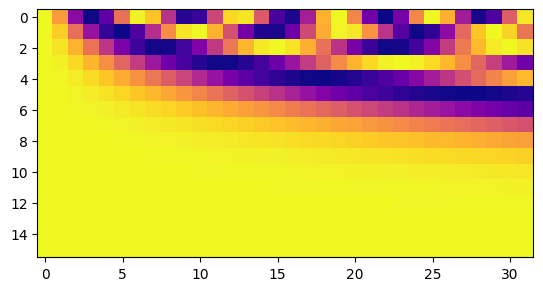

In [17]:
plt.imshow(attention.rotary_embedding.complex_frequencies[0, 0, ..., 0, :].cpu().float().mT, cmap='plasma')

In [18]:
eval_inp.is_contiguous()

True

In [19]:
attention.differential

True

In [20]:
# %%temit -r 10 -n 3
# attention.requires_gradients(True)
outputs, (att, att_val) = attention(eval_inp[:, :6], verbose=3, get=True)
att.max(), att.min()


Executing Self Attention	Contiguous Input=True
Post Linearization =>

Query =>
tensor([[[[-0.0605,  0.0084, -0.1241,  ..., -0.0842,  0.3264,  0.2741],
          [-0.0607,  0.0084, -0.1244,  ..., -0.0844,  0.3273,  0.2748],
          [-0.0608,  0.0084, -0.1247,  ..., -0.0846,  0.3281,  0.2755],
          ...,
          [-0.0650,  0.0090, -0.1333,  ..., -0.0905,  0.3508,  0.2945],
          [-0.0652,  0.0090, -0.1336,  ..., -0.0907,  0.3516,  0.2952],
          [-0.0653,  0.0090, -0.1340,  ..., -0.0909,  0.3524,  0.2959]],

         [[-0.1276,  0.0176, -0.2615,  ..., -0.1775,  0.6881,  0.5777],
          [-0.1277,  0.0176, -0.2618,  ..., -0.1777,  0.6889,  0.5785],
          [-0.1279,  0.0177, -0.2622,  ..., -0.1779,  0.6898,  0.5792],
          ...,
          [-0.1321,  0.0182, -0.2708,  ..., -0.1838,  0.7124,  0.5982],
          [-0.1322,  0.0183, -0.2711,  ..., -0.1840,  0.7133,  0.5989],
          [-0.1324,  0.0183, -0.2714,  ..., -0.1842,  0.7141,  0.5996]],

         [[-0.0482,  0

(tensor(1., dtype=torch.float64), tensor(0., dtype=torch.float64))

In [21]:
outputs.shape

torch.Size([1, 6, 32, 1])

In [22]:
# torch.sum(torch.randn(1, 1, 4, 32, 1))

In [23]:
def normalize(tensor: Tensor):
    maximum, minimum = tensor.max(), tensor.min()
    if maximum-minimum != 0:
        return (tensor - minimum) / (maximum - minimum)
    else:
        return tensor

In [24]:
att.shape, att_val.shape

(torch.Size([1, 6, 4, 32, 32]), torch.Size([1, 6, 32, 64]))

In [25]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[390., 391., 392.,  ..., 419., 420., 421.]], dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[821., 822., 823.,  ..., 850., 851., 852.]], dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[311., 312., 313.,  ..., 340., 341., 342.]], dtype=torch.float64)


In [26]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)


In [27]:
def plot_attention(attention: Tensor, genome_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
    heads = attention.shape[-3]
    fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]
    if inverse:
        axes = axes[::-1]
    x = 0
    if not randomize:
        indices = torch.arange(records)
    else:
        indices = torch.randperm(attention.size(1))[:records]
    for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
        for j, att_head in enumerate(record):
            axes[x].imshow(att_head.float().cpu(), cmap=cmap)
            x += 1
    plt.show()
    return att_head

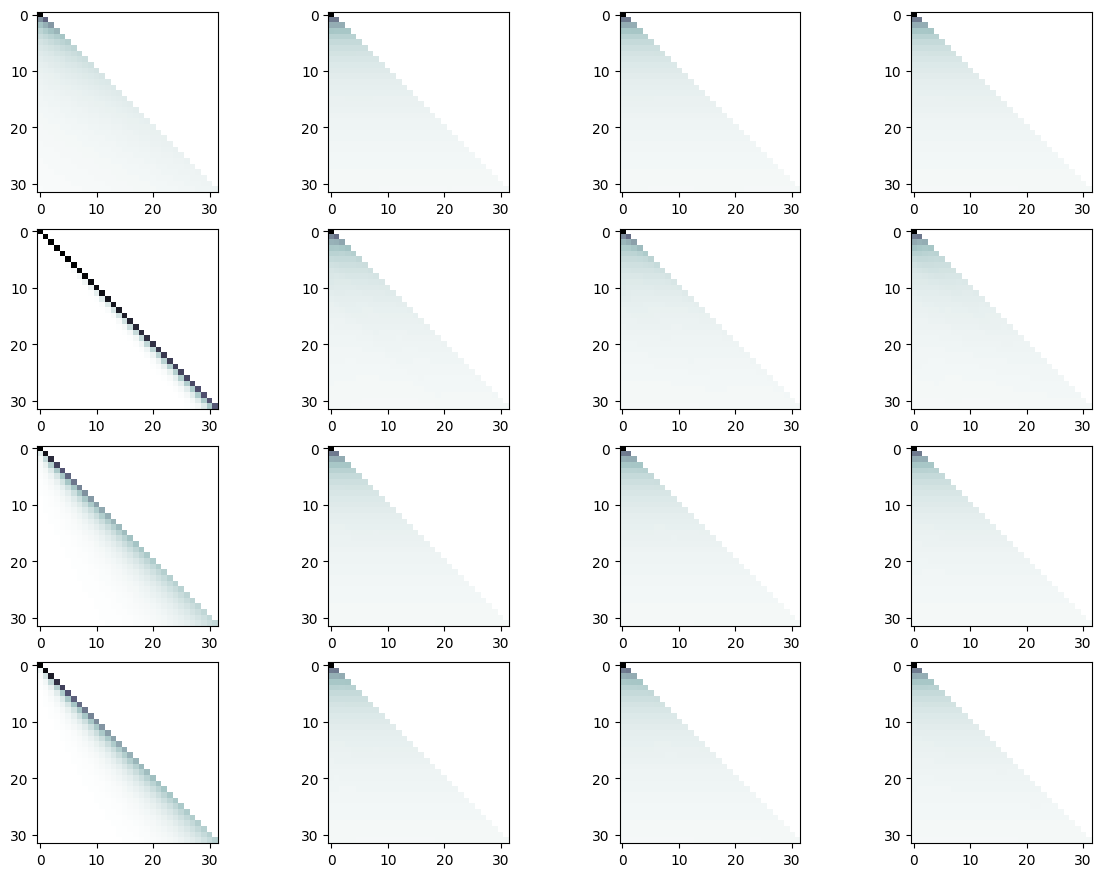

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.49752301, 0.50247699, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33463266, 0.33157437, 0.33379297, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.03276775, 0.03284156, 0.03288455, ..., 0.03384122, 0.        ,
        0.        ],
       [0.03164137, 0.03174429, 0.03181389, ..., 0.0327324 , 0.03275826,
        0.        ],
       [0.03059204, 0.03068773, 0.03078499, ..., 0.03174614, 0.03172   ,
        0.03174446]])

In [28]:
ah = plot_attention(att, 0, 4, True)
ah.cpu().numpy()

In [29]:
def accuracy(prediction, target, error=0.01):
    prediction, target = prediction*divider, target*divider
    total = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    acc = (total.float().count_nonzero() / target.numel()).item()
    return np.round(acc, 4) * 100

In [30]:
accuracy(attention(eval_inp), eval_out)

0.0

In [31]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    attention.requires_gradients(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs
    best_loss = F.mse_loss(attention(train_inp), train_out)
    best_epoch = -1
    save_state = attention.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = attention(train_inp)
            loss = F.mse_loss(test_actv, train_out)
            # loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = attention.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break

    attention.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    attention.requires_gradients(False)
    torch.cuda.empty_cache()
    return losses

training | loss= 6.7300e+00 | best= 6.7300e+00 | epoch=-1: progress=100% eta=0sec

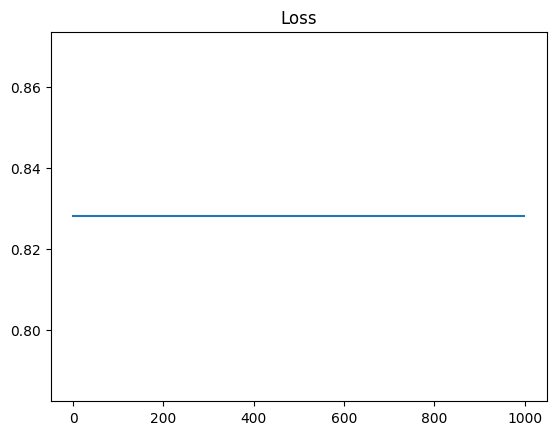

In [32]:
train(1000);

In [33]:
accuracy(attention(eval_inp), eval_out), accuracy(attention(train_inp), train_out)

(0.0, 0.0)

In [34]:
outputs, (att, att_val) = attention(eval_inp, verbose=True, get=True)
att.max(), att.min()


Executing Self Attention	Contiguous Input=True
Post Linearization =>

Query =>
tensor([[[[-6.0516e-02,  8.3532e-03, -1.2407e-01,  ..., -8.4201e-02,
            3.2643e-01,  2.7408e-01],
          [-6.0672e-02,  8.3747e-03, -1.2438e-01,  ..., -8.4417e-02,
            3.2727e-01,  2.7478e-01],
          [-6.0827e-02,  8.3962e-03, -1.2470e-01,  ..., -8.4634e-02,
            3.2811e-01,  2.7549e-01],
          ...,
          [-6.5028e-02,  8.9760e-03, -1.3331e-01,  ..., -9.0478e-02,
            3.5077e-01,  2.9451e-01],
          [-6.5183e-02,  8.9975e-03, -1.3363e-01,  ..., -9.0694e-02,
            3.5161e-01,  2.9522e-01],
          [-6.5339e-02,  9.0189e-03, -1.3395e-01,  ..., -9.0911e-02,
            3.5245e-01,  2.9592e-01]],

         [[-1.2757e-01,  1.7608e-02, -2.6153e-01,  ..., -1.7749e-01,
            6.8811e-01,  5.7775e-01],
          [-1.2772e-01,  1.7630e-02, -2.6184e-01,  ..., -1.7771e-01,
            6.8895e-01,  5.7845e-01],
          [-1.2788e-01,  1.7651e-02, -2.6216e-0

(tensor(1., dtype=torch.float64), tensor(0., dtype=torch.float64))

In [35]:
for i, att_head in enumerate(eval_out[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[390., 391., 392.,  ..., 419., 420., 421.]], dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[821., 822., 823.,  ..., 850., 851., 852.]], dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[311., 312., 313.,  ..., 340., 341., 342.]], dtype=torch.float64)
Record 4: torch.Size([1, 32])
tensor([[872., 873., 874.,  ..., 901., 902., 903.]], dtype=torch.float64)
Record 5: torch.Size([1, 32])
tensor([[139., 140., 141.,  ..., 168., 169., 170.]], dtype=torch.float64)
Record 6: torch.Size([1, 32])
tensor([[350., 351., 352.,  ..., 379., 380., 381.]], dtype=torch.float64)


In [36]:
for i, att_head in enumerate(outputs[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 4: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 5: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)
Record 6: torch.Size([1, 32])
tensor([[3179., 3179., 3179.,  ..., 3179., 3179., 3179.]], dtype=torch.float64)


In [37]:
for i, att_head in enumerate(eval_inp[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[389., 390., 391.,  ..., 418., 419., 420.]], dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[820., 821., 822.,  ..., 849., 850., 851.]], dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[310., 311., 312.,  ..., 339., 340., 341.]], dtype=torch.float64)
Record 4: torch.Size([1, 32])
tensor([[871., 872., 873.,  ..., 900., 901., 902.]], dtype=torch.float64)
Record 5: torch.Size([1, 32])
tensor([[138., 139., 140.,  ..., 167., 168., 169.]], dtype=torch.float64)
Record 6: torch.Size([1, 32])
tensor([[349., 350., 351.,  ..., 378., 379., 380.]], dtype=torch.float64)


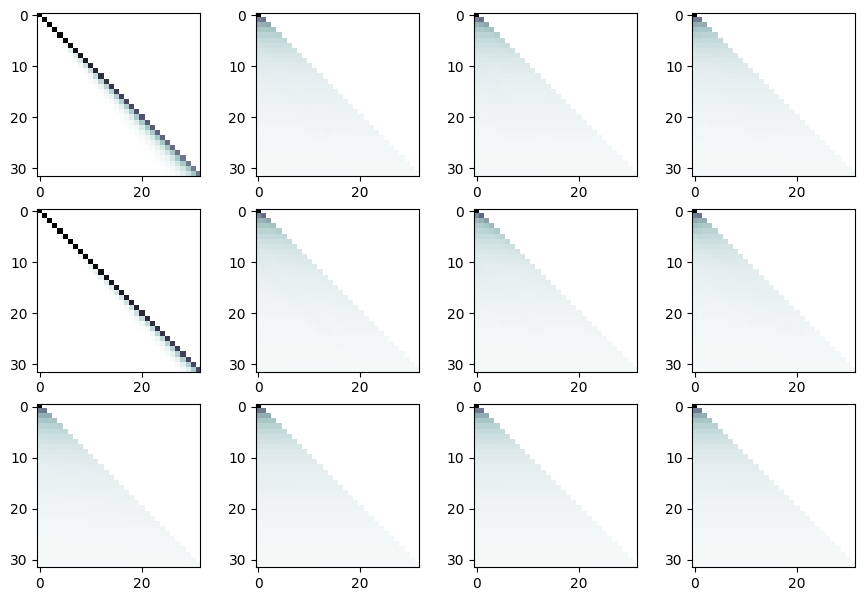

tensor([[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.4998, 0.5002, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3334,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0333, 0.0333, 0.0333,  ..., 0.0334, 0.0000, 0.0000],
        [0.0322, 0.0322, 0.0322,  ..., 0.0323, 0.0323, 0.0000],
        [0.0312, 0.0312, 0.0312,  ..., 0.0313, 0.0313, 0.0313]],
       dtype=torch.float64)

In [38]:
plot_attention(att, 0, 3, True, size=(1080, 720))

tensor([[ 0,  1,  2,  ...,  7,  8,  9],
        [10, 11, 12,  ..., 17, 18, 19],
        [20, 21, 22,  ..., 27, 28, 29],
        ...,
        [70, 71, 72,  ..., 77, 78, 79],
        [80, 81, 82,  ..., 87, 88, 89],
        [90, 91, 92,  ..., 97, 98, 99]])

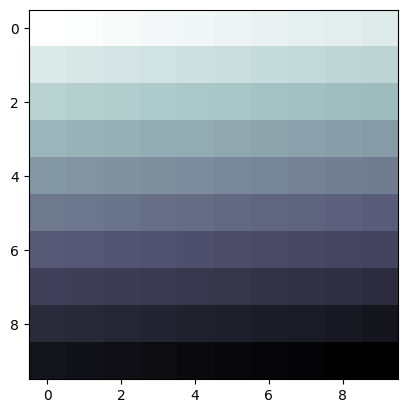

In [39]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)